In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [24]:
#@title Detailed summary plot function for a single simulation

def detailed_plot_single_sim(dt: xr.DataTree, time: float | None = None):
  spr = dt.profiles.spr.sel(rho_norm=dt.rho_cell_norm)
  drho_norm = dt.scalars.drho_norm
  j_ohmic = dt.profiles.j_ohmic
  I_ohm = np.sum(spr*j_ohmic*drho_norm, axis=1)

  jnbi = dt.profiles.j_generic_current
  I_nbi = np.sum(spr*jnbi*drho_norm, axis=1)

  te_line_avg = np.mean(dt.profiles.T_e, axis=1)
  ti_line_avg = np.mean(dt.profiles.T_i, axis=1)

  te_core = dt.profiles.T_e[:, 0]
  te_edge = dt.profiles.T_e[:, -1]
  ti_core = dt.profiles.T_i[:, 0]
  ti_edge = dt.profiles.T_i[:, -1]

  ne_core = dt.profiles.n_e[:, 0]
  ne_edge = dt.profiles.n_e[:, -1]

  pax_new = dt.profiles.pressure_thermal_total.sel(rho_norm=0.0, method='nearest').values


  # Choose a time index for plotting
  if time is None:
    time_index = -1
  else:
    time_index = np.argmin(np.abs(dt.time.values - time))

  _, axes = plt.subplots(4, 5, figsize=(24, 12))

  # Set fontsize
  fsize = 13
  fontreduction = 1
  plt.rcParams.update({'font.size': fsize})

  # ------------------------------
  # --- First Row: T_e, n_e, q, Q
  # ------------------------------

  # Plot Ip
  axes[0, 0].plot(dt.time, dt.profiles.Ip_profile[:, -1]/1e6, 'b-', label=r'$I_p$')
  axes[0, 0].set_xlabel(r"Time [s]")
  axes[0, 0].set_ylabel(r"Plasma current [MA]")
  axes[0, 0].legend(fontsize=fsize-fontreduction)

  # Plot different components of total current
  axes[0, 1].plot(dt.time, dt.scalars.I_bootstrap/1e6, 'b-', label=r'$I_{bootstrap}$')
  axes[0, 1].plot(dt.time, dt.scalars.I_ecrh/1e6, 'r-', label=r'$I_{ecrh}$')
  axes[0, 1].plot(dt.time, I_ohm/1e6, 'm-', label=r'$I_{ohmic}$')
  axes[0, 1].plot(dt.time, I_nbi/1e6, 'k-', label=r'$I_{nbi}$')
  axes[0, 1].set_xlabel(r"Time [s]")
  axes[0, 1].set_ylabel(r"Current [MA]")
  axes[0, 1].legend(fontsize=fsize-fontreduction)
  axes[0, 1].set_title(r"Total currents", fontsize=fsize-fontreduction)

  # Plot Q over time
  axes[0, 2].plot(dt.time[10:], dt.scalars.Q_fusion[10:], 'r-')
  axes[0, 2].set_xlabel("Time [s]")
  axes[0, 2].set_ylabel(r"Q")
  axes[0, 2].set_title(r"Fusion Q", fontsize=fsize-fontreduction)

  # Plot H20 over time
  axes[0, 3].plot(dt.time[10:], dt.scalars.H20[10:], 'r-')
  axes[0, 3].set_xlabel("Time [s]")
  axes[0, 3].set_ylabel(r"H20")
  axes[0, 3].set_title(r"H20 confinement factor", fontsize=fsize-fontreduction)

  # # Plot line_averaged temperatures over time
  # # axes[0, 4].plot(dt.time, te_line_avg, 'r-', label=r'$\langle T_e \rangle$')
  # # axes[0, 4].plot(dt.time, ti_line_avg, 'b-', label=r'$\langle T_i \rangle$')
  # axes[0, 4].plot(dt.time, te_core, 'r-', label=r'$T_{e,core}$')
  # # axes[0, 4].plot(dt.time, te_edge, 'r--', label=r'$T_{e,edge}$')
  # axes[0, 4].plot(dt.time, ti_core, 'b-', label=r'$T_{i,core}$')
  # # axes[0, 4].plot(dt.time, ti_edge, 'b--', label=r'$T_{i,edge}$')
  # axes[0, 4].set_xlabel("Time [s]")
  # axes[0, 4].set_ylabel(r"Temperature [keV]")
  # axes[0, 4].set_title(r"Temps", fontsize=fsize-fontreduction)
  # axes[0, 4].legend(fontsize=fsize-fontreduction)
  
    # Plot densities over time
  # axes[0, 4].plot(dt.time, te_line_avg, 'r-', label=r'$\langle T_e \rangle$')
  # axes[0, 4].plot(dt.time, ti_line_avg, 'b-', label=r'$\langle T_i \rangle$')
  # axes[0, 4].plot(dt.time, ne_core, 'r-', label=r'$n_{e,core}$')
  # axes[0, 4].plot(dt.time, te_edge, 'r--', label=r'$T_{e,edge}$')
  # axes[0, 4].plot(dt.time, ti_core, 'b-', label=r'$T_{i,core}$')
  axes[0,4].plot(dt.time, pax_new, label = 'pax')
  # axes[0, 4].plot(dt.time, ti_edge, 'b--', label=r'$T_{i,edge}$')
  axes[0, 4].set_xlabel("Time [s]")
  axes[0, 4].set_ylabel(r"Pressure on axis (Pa)")
  axes[0, 4].set_title(r"Pressure on axis", fontsize=fsize-fontreduction)
  axes[0, 4].legend(fontsize=fsize-fontreduction)
  
  # ------------------------------
  # --- Second Row: Vloop, T_e, n_e, q, Q
  # ------------------------------

  # Plot Vloop and (TODO) li3 over time
  axes[1, 0].plot(dt.time, dt.scalars.v_loop_lcfs, 'r-')
  # axes[1, 0].plot(dt.time, dt.scalars.li3, 'b-')
  axes[1, 0].set_xlabel("Time [s]")
  axes[1, 0].set_ylabel(r"$V_{loop}(LCFS)$")
  axes[1, 0].set_title(r"Loop voltage (at LCFS)", fontsize=fsize-fontreduction)

  # Plot total powers
  axes[1, 1].plot(dt.time, dt.scalars.P_ecrh_e/1e6, 'b-', label=r'$P_{ECRH}$')
  axes[1, 1].plot(dt.time, dt.scalars.P_aux_generic_total/1e6, 'r-', label=r'$P_{NBI}$')
  axes[1, 1].plot(dt.time, dt.scalars.P_ohmic_e/1e6, 'm-', label=r'$P_{ohmic}$')
  axes[1, 1].plot(dt.time, dt.scalars.P_alpha_total/1e6/5, 'k-', label=r'$P_{fusion}/5$')
  axes[1, 1].set_xlabel("Time [s]")
  axes[1, 1].set_ylabel(r"Heating powers $[MW]$")
  axes[1, 1].legend(fontsize=fsize-fontreduction)
  axes[1, 1].set_title(r"Total heating powers", fontsize=fsize-fontreduction)

  # Plot total sinks
  axes[1, 2].plot(dt.time, dt.scalars.P_cyclotron_e/1e6, 'b-', label=r'$P_{cyclotron}$')
  axes[1, 2].plot(dt.time, dt.scalars.P_radiation_e/1e6, 'r-', label=r'$P_{radiation}+P_{brems}$')
  axes[1, 2].set_xlabel("Time [s]")
  axes[1, 2].set_ylabel(r"Heating sinks $[MW]$")
  axes[1, 2].legend(fontsize=fsize-fontreduction)
  axes[1, 2].set_title(r"Total sinks", fontsize=fsize-fontreduction)

  # Plot q-profile elements
  axes[1, 3].plot(dt.time, dt.scalars.q_min, 'b-', label=r'$q_{min}$')
  axes[1, 3].plot(dt.time, dt.profiles.q[:, 0], 'r-', label=r'$q_{0}$')
  axes[1, 3].plot(dt.time, dt.scalars.q95, 'm-', label=r'$q_{95}$')
  axes[1, 3].set_xlabel("Time [s]")
  axes[1, 3].set_ylabel(r"$q$")
  axes[1, 3].legend(fontsize=fsize-fontreduction)
  axes[1, 3].set_title(r"Safety factor (q) at various rho", fontsize=fsize-fontreduction)

  # Plot normalized inductance over time
  axes[1, 4].plot(dt.time, dt.scalars.li3, 'r-')
  axes[1, 4].set_xlabel("Time [s]")
  axes[1, 4].set_ylabel(r"li(3)")
  axes[1, 4].set_title(r"Normalized internal inductance", fontsize=fsize-fontreduction)

  # ----------------------
  # --- Third Row: T_i,T_e, n_e,n_i, q, shear
  # ----------------------

  # Plot heat transport coefficients
  axes[2, 0].plot(dt.rho_face_norm, dt.profiles.chi_turb_e[time_index, :], 'b-', label=r'$\chi_e$')
  axes[2, 0].plot(dt.rho_face_norm, dt.profiles.chi_turb_i[time_index, :], 'r-', label=r'$\chi_i$')
  axes[2, 0].set_xlabel(r"Normalized Radius ($\hat{\rho}$)")
  axes[2, 0].set_ylabel(r"Heat conductivity $[m^2/s]")
  axes[2, 0].legend(fontsize=fsize-fontreduction)
  axes[2, 0].set_title(r"Heat transport coefficients", fontsize=fsize-fontreduction)

  # Plot T_i and T_e:
  axes[2, 1].plot(dt.rho_norm, dt.profiles.T_e[time_index, :], 'b-', label=r'$T_e$')
  axes[2, 1].plot(dt.rho_norm, dt.profiles.T_i[time_index, :], 'r-', label=r'$T_i$')
  axes[2, 1].set_xlabel(r"Normalized Radius ($\hat{\rho}$)")
  axes[2, 1].set_ylabel(r"Temperature [keV]")
  axes[2, 1].legend(fontsize=fsize-fontreduction)
  axes[2, 1].set_title(r"Temperature profiles", fontsize=fsize-fontreduction)

  # Plot n_e+n_i:
  axes[2, 2].plot(dt.rho_norm, dt.profiles.n_e[time_index, :], 'b-', label=r'$n_e$')
  axes[2, 2].plot(dt.rho_norm, dt.profiles.n_i[time_index, :], 'b--', label=r'$n_i$')
  axes[2, 2].set_xlabel(r"Normalized Radius ($\hat{\rho}$)")
  axes[2, 2].set_ylabel(r"Density [$10^{20} m^{-3}$]")
  axes[2, 2].legend(fontsize=fsize-fontreduction)
  axes[2, 2].set_title(r"$n_e$, $n_i$", fontsize=fsize-fontreduction)

  # Plot q:
  axes[2, 3].plot(dt.rho_face_norm, dt.profiles.q[time_index, :], 'b-', label='q')
  axes[2, 3].set_xlabel(r"Normalized Radius ($\hat{\rho}$)")
  axes[2, 3].set_ylabel(r"q")
  axes[2, 3].legend(fontsize=fsize-fontreduction)
  axes[2, 3].set_title(r"Safety Factor ($q$)", fontsize=fsize-fontreduction)

  # Plot s:
  axes[2, 4].plot(dt.rho_face_norm, dt.profiles.magnetic_shear[time_index, :], 'b-', label=r'$\hat{s}$')
  axes[2, 4].set_xlabel(r"Normalized Radius ($\hat{\rho}$)")
  axes[2, 4].set_ylabel(r"$\hat{s}$")
  axes[2, 4].legend(fontsize=fsize-fontreduction)
  axes[2, 4].set_title(r"Magnetic shear ($\hat{s}$)", fontsize=fsize-fontreduction)

  # ----------------------
  # --- Fourth Row: Sources+sink profiles+current profiles
  # ----------------------

  # Plot psidot
  psidot = dt.profiles.v_loop[time_index, :]
  ymin = min(min(psidot),0)*1.2
  ymax = max(max(psidot),0)*1.2
  axes[3, 0].plot(dt.rho_norm, psidot, 'b-')
  axes[3, 0].set_xlabel(r"Normalized Radius ($\hat{\rho}$)")
  axes[3, 0].set_ylabel(r"Vloop [V]")
  axes[3, 0].set_ylim([ymin, ymax])
  axes[3, 0].set_title(r"Loop voltage profile", fontsize=fsize-fontreduction)

  # Plot total currents
  axes[3, 1].plot(dt.rho_norm, dt.profiles.j_total[time_index, :]/1e6, 'b-', label=r'$j_{total}$')
  axes[3, 1].set_xlabel(r"Normalized Radius ($\hat{\rho}$)")
  axes[3, 1].set_ylabel(r"Currents $[MA/m^2]$")
  axes[3, 1].legend(fontsize=fsize-fontreduction)
  axes[3, 1].set_title(r"Total current density", fontsize=fsize-fontreduction)

  # Plot separate currents
  axes[3, 2].plot(dt.rho_cell_norm, dt.profiles.j_ecrh[time_index, :]/1e6, 'b-', label=r'$j_{ecrh}$')
  axes[3, 2].plot(dt.rho_cell_norm, dt.profiles.j_generic_current[time_index, :]/1e6, 'r-', label=r'$j_{nbi}$')
  axes[3, 2].plot(dt.rho_cell_norm, dt.profiles.j_ohmic[time_index, :]/1e6, 'm-', label=r'$j_{ohmic}$')
  axes[3, 2].plot(dt.rho_norm, dt.profiles.j_bootstrap[time_index, :]/1e6, 'g-', label=r'$j_{bootsrap}$')
  axes[3, 2].set_xlabel(r"Normalized Radius ($\hat{\rho}$)")
  axes[3, 2].set_ylabel(r"Currents $[MA/m^2]$")
  axes[3, 2].legend(fontsize=fsize-fontreduction)
  axes[3, 2].set_title(r"Current source densities", fontsize=fsize-fontreduction)

  # Plot Radiation
  axes[3, 3].plot(dt.rho_cell_norm, dt.profiles.p_impurity_radiation_e[time_index, :]/1e6, 'b-', label=r'$P_{rad}$')
  axes[3, 3].set_xlabel(r"Normalized Radius ($\hat{\rho}$)")
  axes[3, 3].set_ylabel(r"Heat sink density $[MW/m^3]$")
  axes[3, 3].legend(fontsize=fsize-fontreduction)
  axes[3, 3].set_title(r"Radiation heat sink", fontsize=fsize-fontreduction)

  # Plot external sources
  axes[3, 4].plot(dt.rho_cell_norm, dt.profiles.p_ecrh_e[time_index, :]/1e6, 'b-', label=r'$Q_{ecrh}$')
  axes[3, 4].plot(dt.rho_cell_norm, dt.profiles.p_generic_heat_i[time_index, :]/1e6, 'r-', label=r'$Q_{nbi_i}$')
  axes[3, 4].plot(dt.rho_cell_norm, dt.profiles.p_generic_heat_e[time_index, :]/1e6, 'm-', label=r'$Q_{nbi_e}$')
  axes[3, 4].plot(dt.rho_cell_norm, dt.profiles.p_alpha_i[time_index, :]/1e6, 'g-', label=r'$Q_{fus_i}$')
  axes[3, 4].plot(dt.rho_cell_norm, dt.profiles.p_alpha_e[time_index, :]/1e6, 'k-', label=r'$Q_{fus_e}$')
  axes[3, 4].set_xlabel(r"Normalized Radius ($\hat{\rho}$)")
  axes[3, 4].set_ylabel(r"Heat source densities $[MW/m^3]$")
  axes[3, 4].legend(fontsize=fsize-fontreduction)
  axes[3, 4].set_title(r"Heat sources", fontsize=fsize-fontreduction)

  # Plot fusion sources

  plt.tight_layout()

  plt.show()


2026-02-23 15:16:59,247 [    INFO] Precision is set at float64
2026-02-23 15:16:59,248 [    INFO] Starting simulation.
Simulating:   0%|          | 0/100 [00:00<?, ?it/s]

Simulating (t=200.00000): 100%|██████████| 100/100 [00:04<00:00, 24.11it/s]
2026-02-23 15:17:03,399 [    INFO] Simulated 200.00s of physics in 4.15s of wall clock time.


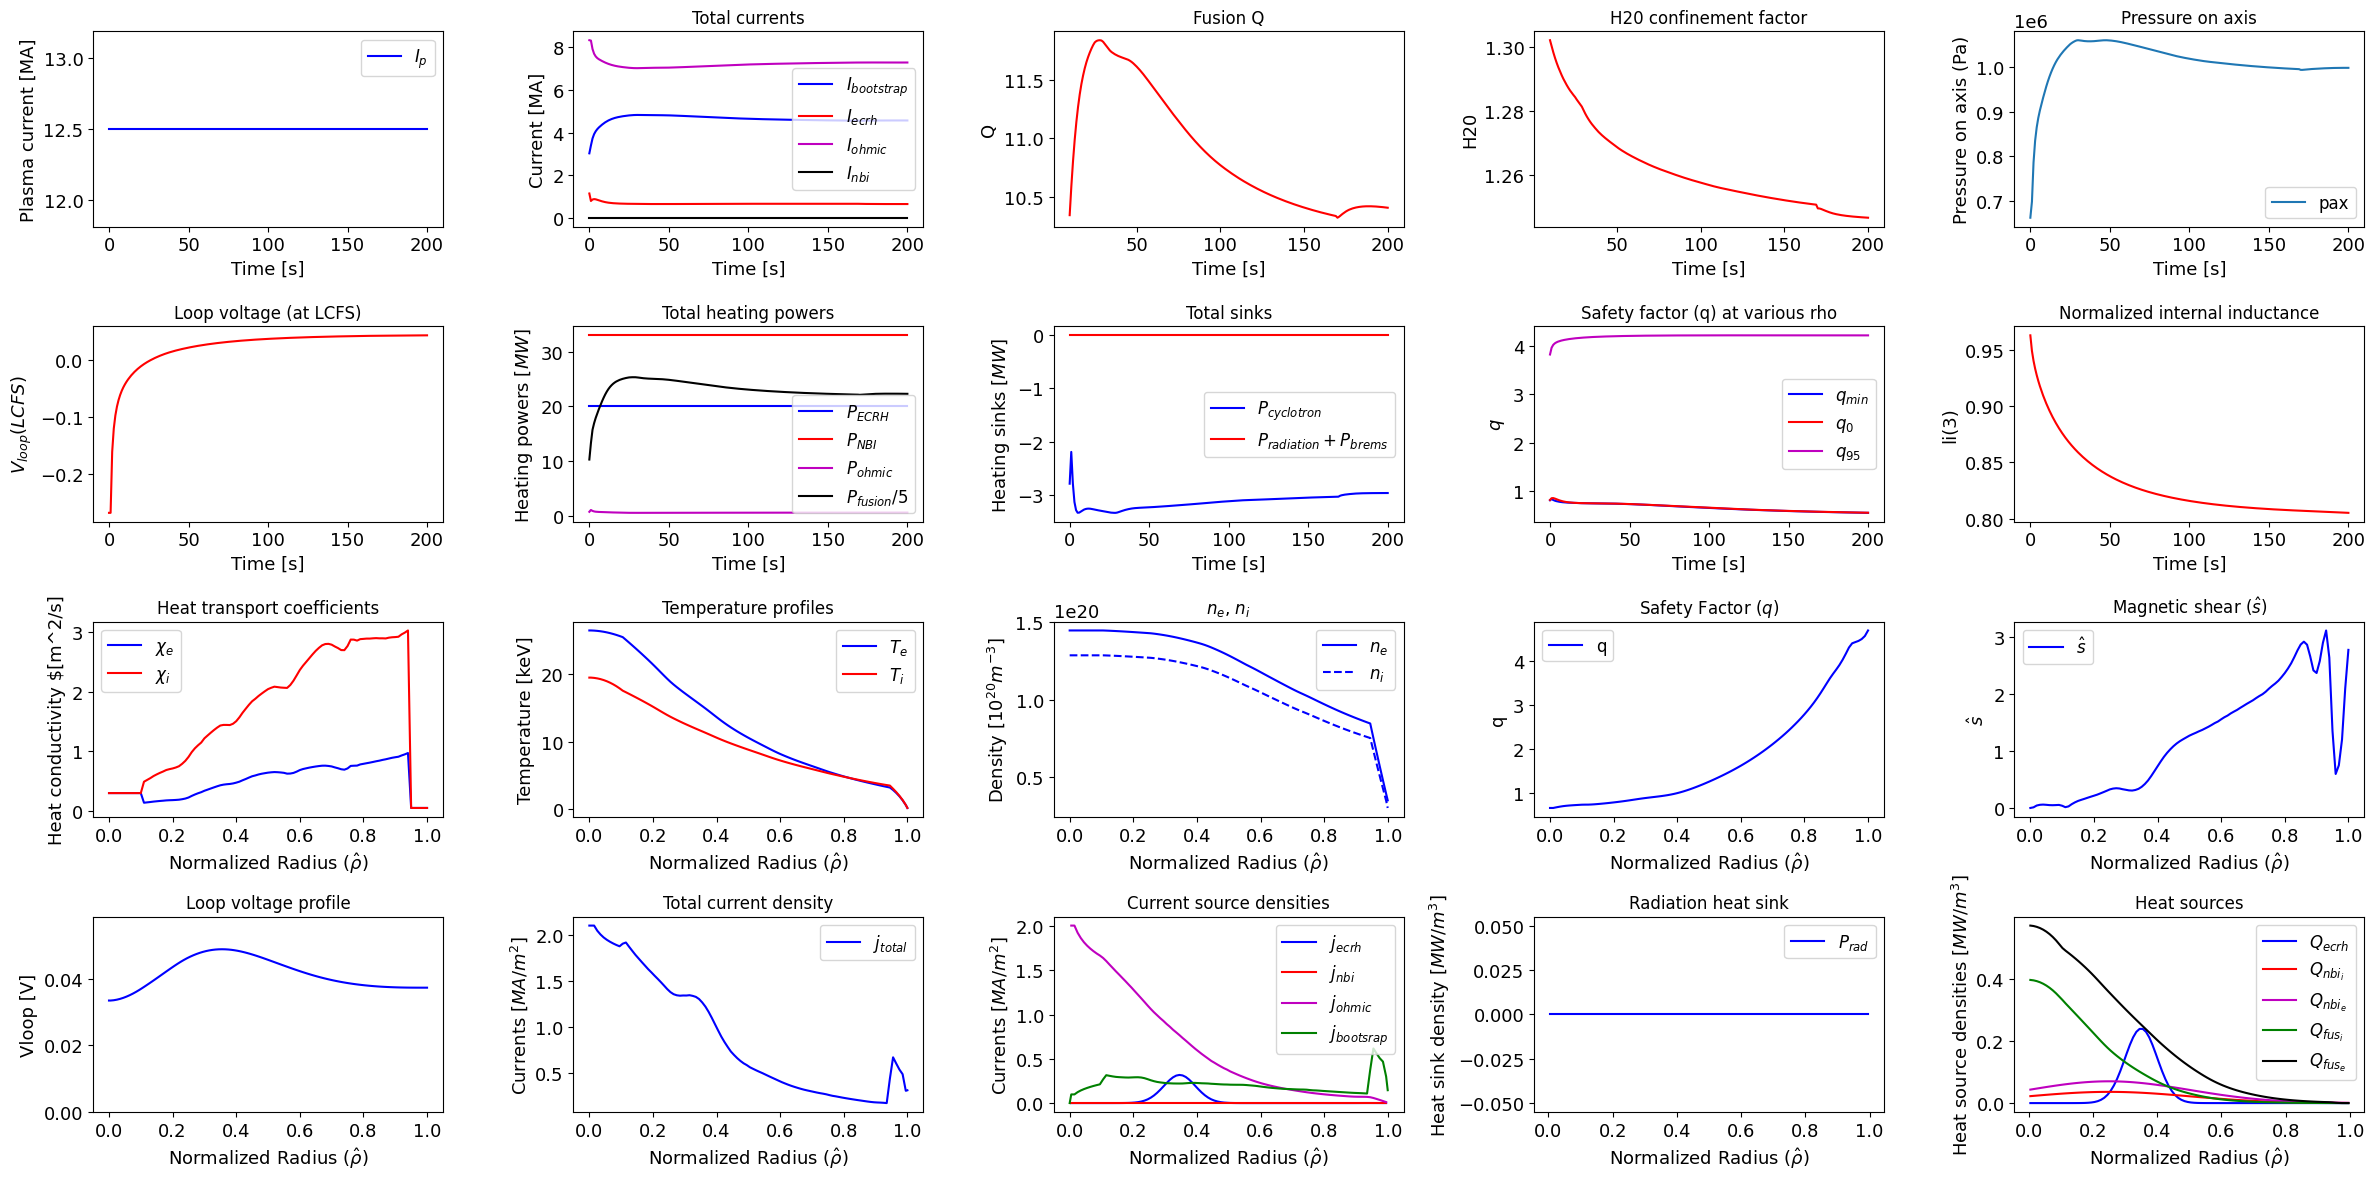

In [25]:
# @title Flattop-only simulation (100 seconds, no rampup)
# Self-contained cell: full config with all flattop values baked in.
# Based on ITER hybrid scenario (van Mulders Nucl. Fusion 2021).
# All time-dependent parameters are held constant at their flattop values.
# No rampup — simulation begins at t=0 with full flattop current, heating, and pedestal.

import copy
import jax
import torax
import numpy as np
from typing import Any

jax.config.update('jax_enable_x64', True)

# ── NBI parametrisation ──────────────────────────────────────────────────────
_NBI_W_TO_MA = 1 / 16e6   # rough NBI power-to-current-drive conversion [A/W]
r_nbi = 0.25               # Gaussian deposition location [rho_norm]
w_nbi = 0.25               # Gaussian deposition width   [rho_norm]
el_heat_fraction = 0.66    # electron heating fraction

# ── Full flattop config ───────────────────────────────────────────────────────
config_flattop = {
    'plasma_composition': {
        'main_ion': {'D': 0.5, 'T': 0.5},          # D-T 50/50
        'impurity': {'Ne': 1.0, 'W': 0.0},         # pure neon impurity
        'Z_eff': {0.0: {0.0: 2.0, 1.0: 2.0}},      # radially uniform Z_eff = 2
    },
    'profile_conditions': {
        # ── Current ─────────────────────────────────────────────────────────
        'Ip': {0: 12.5e6},                          # 12.5 MA, constant
        # ── Initial temperature profiles ────────────────────────────────────
        'T_i': {0.0: {0.0: 19.0, 1.0: 0.2}},       # on-axis 20 keV, edge 0.2 keV
        'T_i_right_bc': 0.2,
        'T_e': {0.0: {0.0: 26.0, 1.0: 0.2}},       # on-axis 20 keV, edge 0.2 keV
        'T_e_right_bc': 0.2,
        # ── Initial density profile ──────────────────────────────────────────
        'n_e_right_bc_is_fGW': True,
        'n_e_right_bc': 0.35,                       # constant edge n_e [fGW]
        'nbar': 0.85,                               # line-average n_e [fGW]
        'n_e': {0: {0.0: 1.4, 1.0: 1.0}},          # initial n_e shape (normalised)
        'normalize_n_e_to_nbar': True,
        'n_e_nbar_is_fGW': True,
        # ── Current initialisation ───────────────────────────────────────────
        'initial_psi_from_j': True,
        'initial_j_is_total_current': True,
        'current_profile_nu': 2,
    },
    'numerics': {
        't_final': 200,                             # 100 s of flattop
        'fixed_dt': 1,
        'evolve_ion_heat': True,
        'evolve_electron_heat': True,
        'evolve_current': True,
        'evolve_density': True,
    },
    'geometry': {
        'geometry_type': 'chease',
        'geometry_file': 'iterhybrid.mat2cols',     # ITER hybrid CHEASE file
        'Ip_from_parameters': True,
        'R_major': 6.2,                             # [m]
        'a_minor': 2.0,                             # [m]
        'B_0': 5.3,                                 # [T]
        'n_rho': 100,
    },
    'sources': {
        # ECRH/ECCD — full 20 MW from t=0
        'ecrh': {
            'gaussian_location': 0.35,
            'gaussian_width': 0.05,
            'P_total': {0: 20.0e6},                 # 20 MW, constant
        },
        # NBI heat — full 33 MW from t=0
        'generic_heat': {
            'gaussian_location': r_nbi,
            'gaussian_width': w_nbi,
            'P_total': {0: 33.0e6},                 # 33 MW, constant
            'electron_heat_fraction': el_heat_fraction,
        },
        # NBI current drive
        'generic_current': {
            'use_absolute_current': True,
            'gaussian_location': r_nbi,
            'gaussian_width': w_nbi,
            'I_generic': {0: 33.0e6 * _NBI_W_TO_MA},  # ≈ 2.06 MA, constant
        },
        'fusion': {},
        'ei_exchange': {},
        'ohmic': {},
        'cyclotron_radiation': {},
        'impurity_radiation': {
            'model_name': 'mavrin_fit',
            'radiation_multiplier': 0.0,
        },
    },
    'neoclassical': {
        'bootstrap_current': {
            'bootstrap_multiplier': 1.0,
        },
    },
    'pedestal': {
        'model_name': 'set_T_ped_n_ped',
        'set_pedestal': True,
        'T_i_ped': {0: 3.0},                        # 3.0 keV, constant H-mode
        'T_e_ped': {0: 3.0},                        # 3.0 keV, constant H-mode
        'n_e_ped_is_fGW': True,
        'n_e_ped': 0.85,                            # pedestal n_e = 0.85 fGW
        'rho_norm_ped_top': 0.95,
    },
    'transport': {
        'model_name': 'qlknn',
        'apply_inner_patch': True,
        'D_e_inner': 0.15,
        'V_e_inner': 0.0,
        'chi_i_inner': 0.3,
        'chi_e_inner': 0.3,
        'rho_inner': 0.1,
        'apply_outer_patch': True,
        'D_e_outer': 0.1,
        'V_e_outer': 0.0,
        'chi_i_outer': 2.0,
        'chi_e_outer': 2.0,
        'rho_outer': 0.95,
        'chi_min': 0.05,
        'chi_max': 100,
        'D_e_min': 0.05,
        'D_e_max': 50,
        'V_e_min': -10,
        'V_e_max': 10,
        'smoothing_width': 0.1,
        'DV_effective': True,
        'include_ITG': True,
        'include_TEM': True,
        'include_ETG': True,
        'avoid_big_negative_s': False,
    },
    'solver': {
        'solver_type': 'linear',
        'use_predictor_corrector': True,
        'n_corrector_steps': 10,
        'chi_pereverzev': 30,
        'D_pereverzev': 15,
        'use_pereverzev': True,
    },
    'time_step_calculator': {
        'calculator_type': 'fixed',
    },
}

# ── Run simulation ────────────────────────────────────────────────────────────
torax_config_ft = torax.ToraxConfig.from_dict(config_flattop)
data_tree, _ = torax.run_simulation(torax_config_ft, log_timestep_info=False)

# ── Plot end-of-simulation profiles ──────────────────────────────────────────
detailed_plot_single_sim(data_tree, time=100)


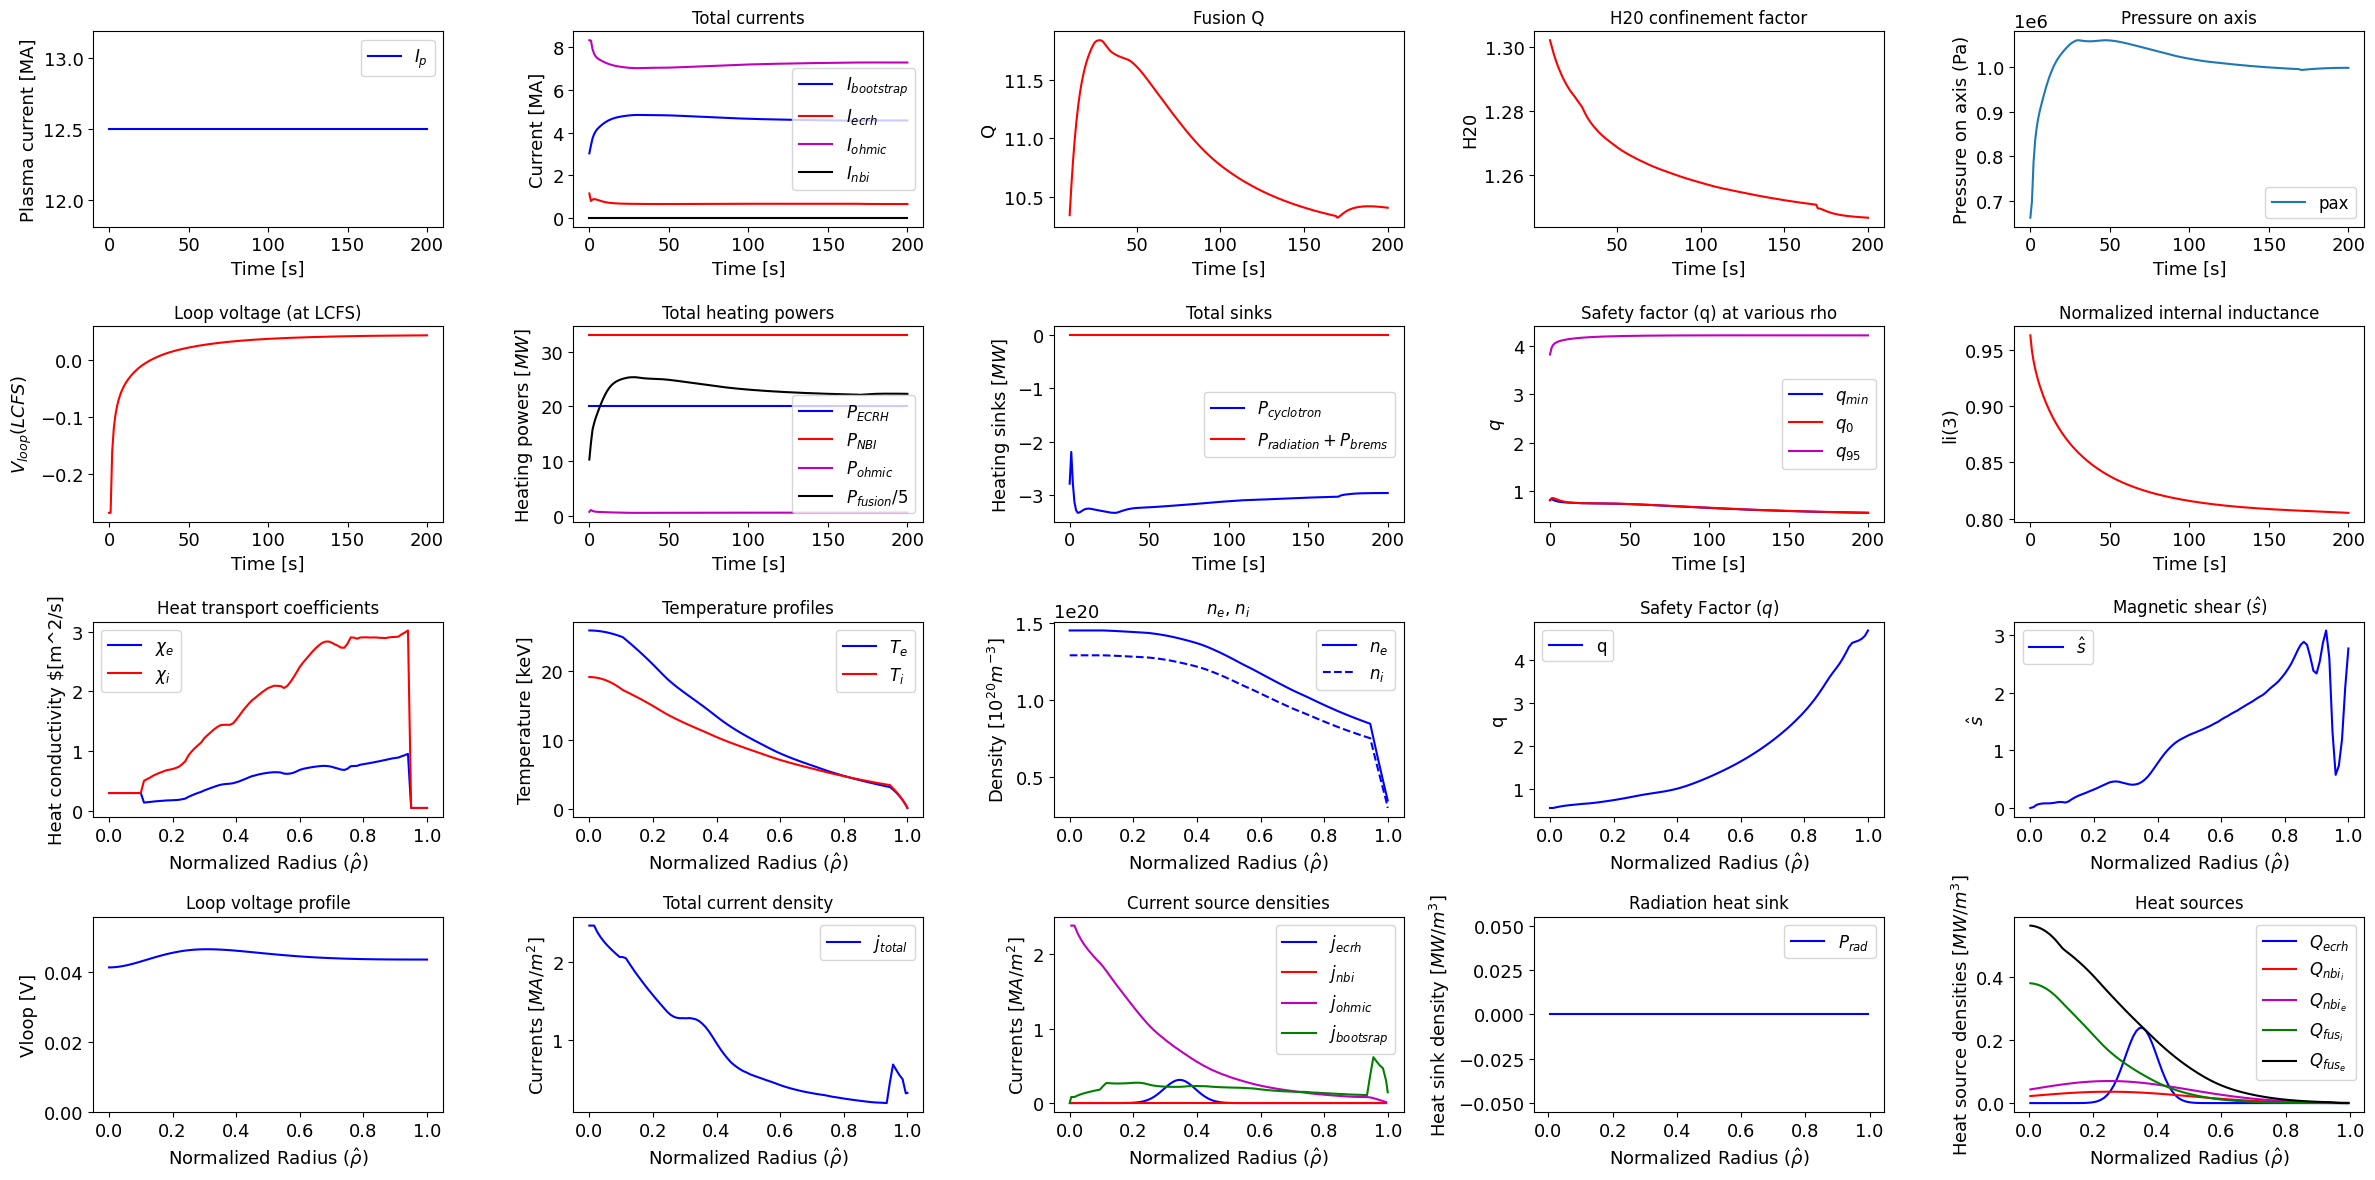

In [26]:
# ── Plot end-of-simulation profiles ──────────────────────────────────────────
detailed_plot_single_sim(data_tree, time=200)

In [ ]:
import numpy as np

# After running data_tree:
t_idx = -1  # last time step
rho   = data_tree.rho_cell_norm.values
T_e   = data_tree.profiles.T_e.isel(time=t_idx).values   # keV
T_i   = data_tree.profiles.T_i.isel(time=t_idx).values   # keV
n_e   = data_tree.profiles.n_e.isel(time=t_idx).values   # m^-3

p_axis_Pa = n_e[0] * (T_e[0] + T_i[0]) * 1e3 * 1.602e-19  # Pa (electrons + ions)
print(f"p_axis = {p_axis_Pa/1e5:.3f} bar  = {p_axis_Pa:.3e} Pa")
print(f"T_e axis = {T_e[0]:.1f} keV,  T_i axis = {T_i[0]:.1f} keV")
print(f"n_e axis = {n_e[0]:.3e} m^-3")

p_axis = 10.424 bar  = 1.042e+06 Pa
T_e axis = 25.8 keV,  T_i axis = 19.1 keV
n_e axis = 1.451e+20 m^-3


Note: geometry shaping not found in DataTree — using literature values.
  TokaMaker equilibrium target parameters
  R_major      = 6.20 m
  a_minor      = 2.00 m   (A = R/a = 3.10)
  B_0          = 5.30 T
  Ip_target    = 12.50 MA
  kappa_95     = 1.720
  delta_95     = 0.330
  Z_0          = 0.0 m  (midplane)

  p'(psi_norm) grid points : 101
  p'  range   : [-3.507e+04, -5.460e+03]  Pa/Wb_norm
  FF' range   : [-1.716e+00, 7.081e-01]  T^2 m^2/Wb_norm


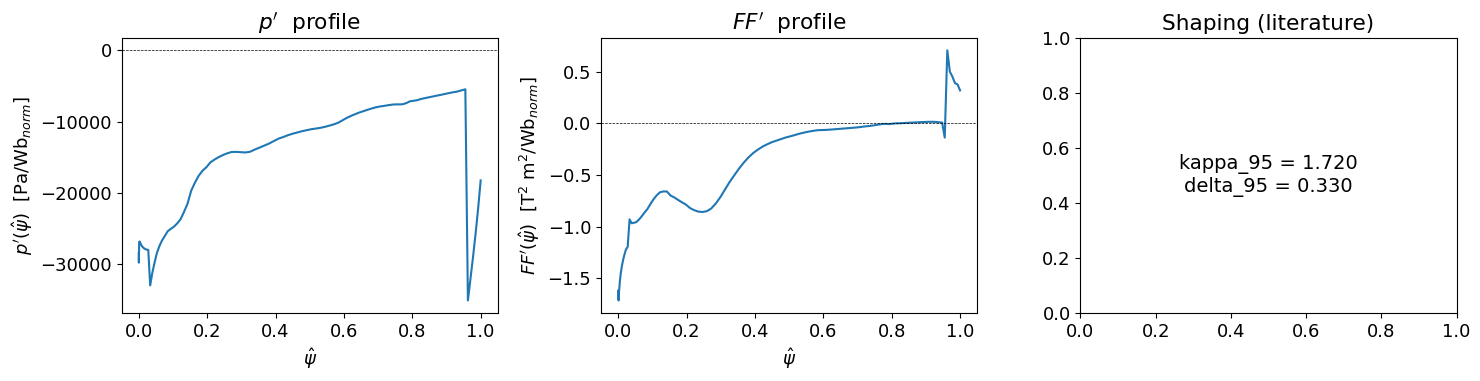

In [ ]:
# @title TokaMaker equilibrium inputs from end of TORAX flattop simulation
# Extracts p'(psi), FF'(psi), and geometric/coil target parameters
# for use as TokaMaker (or other GS solver) inputs.

import numpy as np
import matplotlib.pyplot as plt

MU0 = 4 * np.pi * 1e-7  # [H/m]

# ── Fixed machine / scenario parameters (from config) ────────────────────────
R_major = 6.2    # [m]
a_minor = 2.0    # [m]
B_0     = 5.3    # [T]
Ip_target = 12.5e6  # [A]

# ── Last time-step index ──────────────────────────────────────────────────────
t_idx = -1

# ── Normalized poloidal flux grid (face grid) ─────────────────────────────────
# psi_norm = 0 at magnetic axis, 1 at LCFS
psi_norm = data_tree.profiles.psi_norm.isel(time=t_idx).values   # face grid

# ── p'(psi_norm) and FF'(psi_norm) — directly from TORAX post-processing ─────
# pprime  = dp/dpsi  [Pa / Wb]
# FFprime = F*dF/dpsi  [T^2*m^2/Wb = T^2*m]  (F = R*Bphi, the toroidal function)
pprime  = data_tree.profiles.pprime.isel(time=t_idx).values      # face grid
FFprime = data_tree.profiles.FFprime.isel(time=t_idx).values     # face grid

# ── Shaping parameters from the CHEASE geometry (time-independent) ────────────
# elongation is on the cell grid; delta (triangularity) on the face grid
try:
    kappa = data_tree.profiles.elongation.isel(time=t_idx).values      # cell grid
    delta = data_tree.profiles.delta_face.isel(time=t_idx).values      # face grid
    # Representative 95% surface values (interpolate to psi_norm = 0.95)
    rho_cell = data_tree.rho_cell_norm.values
    rho_face = data_tree.rho_face_norm.values
    kappa_95 = float(np.interp(0.95, rho_cell, kappa))
    delta_95 = float(np.interp(0.95, rho_face, delta))
except Exception:
    # Fallback to literature values for ITER hybrid (van Mulders 2021)
    kappa_95, delta_95 = 1.72, 0.33
    kappa, delta = None, None
    print("Note: geometry shaping not found in DataTree — using literature values.")

# ── Summary print ─────────────────────────────────────────────────────────────
print("=" * 55)
print("  TokaMaker equilibrium target parameters")
print("=" * 55)
print(f"  R_major      = {R_major:.2f} m")
print(f"  a_minor      = {a_minor:.2f} m   (A = R/a = {R_major/a_minor:.2f})")
print(f"  B_0          = {B_0:.2f} T")
print(f"  Ip_target    = {Ip_target/1e6:.2f} MA")
print(f"  kappa_95     = {kappa_95:.3f}")
print(f"  delta_95     = {delta_95:.3f}")
print(f"  Z_0          = 0.0 m  (midplane)")
print()
print(f"  p'(psi_norm) grid points : {len(pprime)}")
print(f"  p'  range   : [{pprime.min():.3e}, {pprime.max():.3e}]  Pa/Wb_norm")
print(f"  FF' range   : [{FFprime.min():.3e}, {FFprime.max():.3e}]  T^2 m^2/Wb_norm")
print("=" * 55)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(psi_norm, pprime)
axes[0].set_xlabel(r"$\hat{\psi}$")
axes[0].set_ylabel(r"$p'(\hat{\psi})$  [Pa/Wb$_{norm}$]")
axes[0].set_title(r"$p'$  profile")
axes[0].axhline(0, color='k', lw=0.5, ls='--')

axes[1].plot(psi_norm, FFprime)
axes[1].set_xlabel(r"$\hat{\psi}$")
axes[1].set_ylabel(r"$FF'(\hat{\psi})$  [T$^2$ m$^2$/Wb$_{norm}$]")
axes[1].set_title(r"$FF'$  profile")
axes[1].axhline(0, color='k', lw=0.5, ls='--')

if kappa is not None:
    axes[2].plot(rho_cell, kappa, label=r'$\kappa(\rho)$')
    axes[2].plot(rho_face, delta, label=r'$\delta(\rho)$')
    axes[2].axvline(0.95, color='grey', ls='--', lw=0.8, label=r'$\rho_{95}$')
    axes[2].set_xlabel(r"$\rho_{norm}$")
    axes[2].set_title("Shaping profiles")
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, f'kappa_95 = {kappa_95:.3f}\ndelta_95 = {delta_95:.3f}',
                 ha='center', va='center', fontsize=14, transform=axes[2].transAxes)
    axes[2].set_title("Shaping (literature)")

plt.tight_layout()
plt.show()


In [6]:
# load libraries and setup tokamaker
import os
import sys
import numpy as np
import time
import matplotlib.pyplot as plt
from omfit_classes.utils_fusion import sauter_bootstrap, Hmode_profiles

plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

tokamaker_python_path = os.getenv('OFT_ROOTPATH')

if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, create_power_flux_fun
# from OpenFUSIONToolkit.TokaMaker.bootstrap import solve_with_bootstrap

myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('ITER_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.settings.maxits=100


#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           51e08bd
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/9p/90ydvncx0zb8sqr976fmrfxr0000gn/T/oft_72117/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  2.859E+02
    # of points  =    4757
    # of edges   =   14156
    # of cells   =    9400
    # of boundary points =     112
    # of boundary edges  =     112
    # of boundary cells  =     112
  Resolution statistics:
    hmin =  9.924E-03
    hrms =  2.826E-01
    hmax =  8.466E-01
  Surface grounded at vertex     870

